In [ ]:
# analysis 1: find top-K courses per DS job and count how often each course appears
# it shows which courses are consistently valuable across many job types, indicating strong signal for courses. 

In [2]:
from collections import Counter 
import numpy as np
similarity_scores_Course_Job = np.load("similarity_scores_Course_Job.npy")

# count occurrences of elements. 

In [3]:
similarity_scores_Course_Job.shape

(55, 974)

In [4]:
import pandas as pd
df_loaded_courses = pd.read_csv('df_loaded_courses.csv', header = 0, names = ['course_code', 'course_name', 'course_description',"course_url","combined_text"])


In [5]:
df_loaded_jobs = pd.read_csv('df_loaded_jobs.csv', header = 0, names = ['Country', 'Company', 'Job Title',"Job Description","URL","Full Job Description","combined_text","similarity_score"])

In [6]:
len(df_loaded_courses)

974

In [7]:
len(df_loaded_jobs)

55

In [8]:
df_loaded_courses[:10]

,course_code,course_name,course_description,course_url,combined_text
0,ENGS 1.01,Mathematical Concepts in Engineering,This course introduces prospective engineering...,https://engineering.dartmouth.edu/courses/unde...,Mathematical Concepts in EngineeringThis cours...
1,ENGS 2,"Integrated Design: Engineering, Architecture, ...",An introduction to the integrated design of st...,https://engineering.dartmouth.edu/courses/unde...,"Integrated Design: Engineering, Architecture, ..."
2,ENGS 3,Materials: The Substance of Civilization,"With the exception of ideas and emotions, mate...",https://engineering.dartmouth.edu/courses/unde...,Materials: The Substance of CivilizationWith t...
3,ENGS 3.10,Elementary Oceanography,Oceanography is one of the studies in which na...,https://engineering.dartmouth.edu/courses/unde...,Elementary OceanographyOceanography is one of ...
4,ENGS 4,Technology of Cyberspace,This course will cover some basic concepts und...,https://engineering.dartmouth.edu/courses/unde...,Technology of CyberspaceThis course will cover...
5,ENGS 5,Healthcare and Biotechnology in the 21st Century,The course will explore technologies that will...,https://engineering.dartmouth.edu/courses/unde...,Healthcare and Biotechnology in the 21st Centu...
6,ENGS 6,Technology and Biosecurity,This course will introduce students to the tec...,https://engineering.dartmouth.edu/courses/unde...,Technology and BiosecurityThis course will int...
7,ENGS 7.02,Climate Change,Climate change has occurred naturally and freq...,https://engineering.dartmouth.edu/courses/unde...,Climate ChangeClimate change has occurred natu...
8,ENGS 7.05,Contemporary and Historical Perspectives on Me...,Medical imaging has evolved significantly over...,https://engineering.dartmouth.edu/courses/unde...,Contemporary and Historical Perspectives on Me...
9,ENGS 7.06,Sustainability Revolution,Humanity has previously seen two major resourc...,https://engineering.dartmouth.edu/courses/unde...,Sustainability RevolutionHumanity has previous...


In [9]:
df_loaded_jobs[:10]

,Country,Company,Job Title,Job Description,URL,Full Job Description,combined_text,similarity_score
0,US,Eli Lilly,Data Scientist (R5-R7),"At Lilly, we unite caring with discovery to ma...",https://www.adzuna.com/details/5248534700?utm_...,"At Lilly, we unite caring with discovery to ma...","Data Scientist (R5-R7) At Lilly, we unite cari...",0.636731
1,US,Eli Lilly,Data Scientist (R5-R7),"At Lilly, we unite caring with discovery to ma...",https://www.adzuna.com/details/5246717556?utm_...,"At Lilly, we unite caring with discovery to ma...","Data Scientist (R5-R7) At Lilly, we unite cari...",0.637432
2,US,Eli Lilly,"Advisor Engineer - Data, Molecule Discovery","At Lilly, we unite caring with discovery to ma...",https://www.adzuna.com/details/5279054822?utm_...,"At Lilly, we unite caring with discovery to ma...","Advisor Engineer - Data, Molecule Discovery At...",0.508027
3,US,Johnson & Johnson,Cheminformatics/Data Scientist - Discovery Che...,"A Minimum of a Bachelor’s degree is required, ...",https://www.adzuna.com/details/4809749561?utm_...,"A Minimum of a Bachelor’s degree is required, ...",Cheminformatics/Data Scientist - Discovery Che...,0.530796
4,US,Johnson & Johnson,Experienced Data Scientist,"At Johnson & Johnson, we believe health is eve...",https://www.adzuna.com/details/5306451413?utm_...,"At Johnson & Johnson, we believe health is eve...",Experienced Data Scientist At Johnson & Johnso...,0.504352
5,US,Johnson & Johnson,Director MT DATA & AI - Data Engineering,"At Johnson & Johnson,?we believe health is eve...",https://www.adzuna.com/details/5307267094?utm_...,"At Johnson & Johnson,?we believe health is eve...",Director MT DATA & AI - Data Engineering At Jo...,0.504939
6,US,Johnson & Johnson,Manager Agentic Data Engineering,"At Johnson & Johnson, we believe health is eve...",https://www.adzuna.com/details/5306451405?utm_...,"At Johnson & Johnson, we believe health is eve...",Manager Agentic Data Engineering At Johnson & ...,0.504921
7,US,Johnson & Johnson,"Senior/Staff Software Engineer, Compute Team","Who we are At Domino, we build software that h...",https://www.adzuna.com/details/5288652416?utm_...,"Who we are At Domino, we build software that h...","Senior/Staff Software Engineer, Compute Team W...",0.542934
8,US,Johnson & Johnson,Lead Data Scientist & AI Developer,"At Johnson & Johnson, we believe health is eve...",https://www.adzuna.com/details/5314587077?utm_...,"At Johnson & Johnson, we believe health is eve...",Lead Data Scientist & AI Developer At Johnson ...,0.610608
9,US,Johnson & Johnson,Lead Data Scientist & AI Developer,"At Johnson & Johnson,?we believe health is eve...",https://www.adzuna.com/details/5313381556?utm_...,"At Johnson & Johnson,?we believe health is eve...",Lead Data Scientist & AI Developer At Johnson ...,0.591871


In [10]:
import pandas as pd

In [11]:
top_k= 3
top3_matched_results = []
for job_idx, sim_row in enumerate(similarity_scores_Course_Job):
    top_indices = sim_row.argsort()[-top_k:][::-1]

    for course_idx in top_indices:
        top3_matched_results.append({
            "Job Title": df_loaded_jobs.loc[job_idx, "Job Title"],
            "Job Description": df_loaded_jobs.loc[job_idx, "Full Job Description"],
            "job_url": df_loaded_jobs.loc[job_idx, "URL"],
            "course_title": df_loaded_courses.loc[course_idx, "course_name"],
            "course_description": df_loaded_courses.loc[course_idx, "course_description"],
            "course_url": df_loaded_courses.loc[course_idx, "course_url"],
            "similarity_scores_Course_Job": sim_row[course_idx]
        })

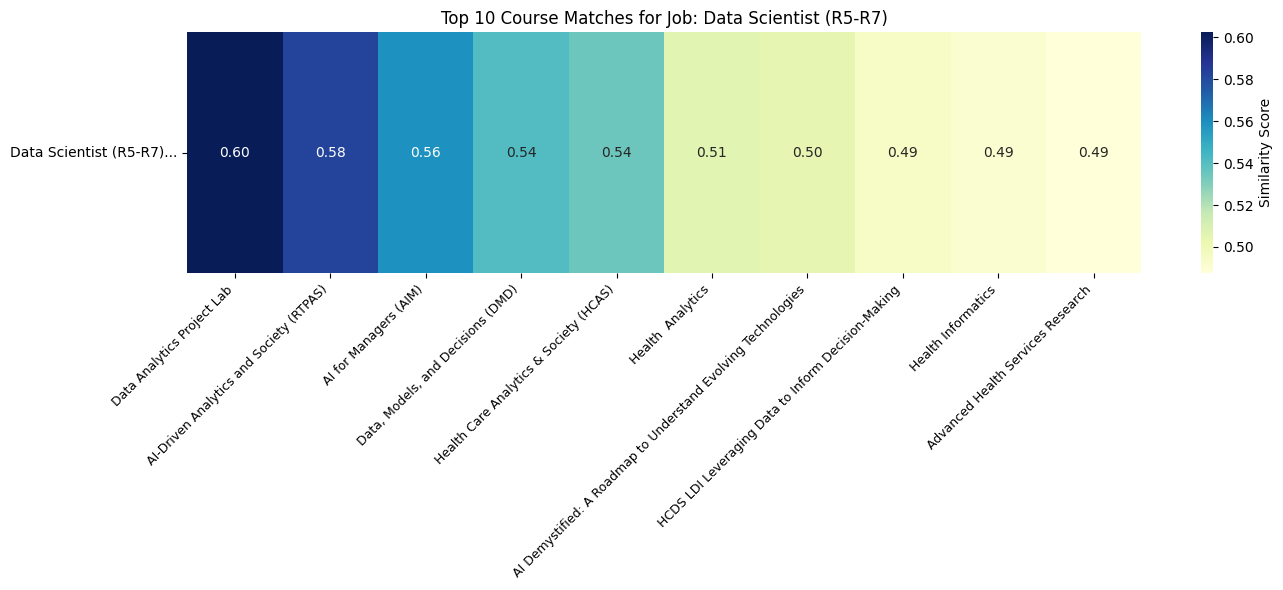

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


job_idx = 0

# Get top 10 matching course indices
top_k = 10
sim_row = similarity_scores_Course_Job[job_idx]
top_indices = sim_row.argsort()[-top_k:][::-1]

# Prepare DataFrame for heatmap
job_title = df_loaded_jobs.loc[job_idx, "Job Title"]
course_names = df_loaded_courses.loc[top_indices, "course_name"].values
scores = sim_row[top_indices]

df_heat = pd.DataFrame(
data=[scores],
index=[job_title[:40] + '...'], 
columns=course_names
)

# Plot
plt.figure(figsize=(14, 6))
sns.heatmap(df_heat, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={"label": "Similarity Score"})
plt.title(f"Top 10 Course Matches for Job: {job_title}")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df_top3 = pd.DataFrame(top3_matched_results)

In [37]:
top3_matched_results[-3:]

[{'Job Title': 'Associate Director, Business Intelligence Architect',
  'Job Description': "The Associate Director, Business Intelligence Architect will play a pivotal role in developing and implementing advanced analytics strategies across global development and driving data-driven decision-making processes at the portfolio, program and functional level by leveraging advanced analytics, data ingesting/cleansing/modeling, and visualization techniques. As the amount of data available continues to grow and cross-department alignment and dependency increase, this individual will be responsible for enhancing how we leverage our data to support creating, developing and delivering metrics and analytics related to the operational performance of running clinical trials along with developing use cases for Artificial Intelligence (AI) within Business Intelligence tools, supporting advanced analytics initiatives, and bridging the gap between technical and business perspectives. The ideal candidat

In [10]:
top_k =3
top_course_counter = Counter()

for sim_row in similarity_scores_Course_Job:
    top_indices = sim_row.argsort()[-top_k:][::-1]
    top_course_counter.update(top_indices)

top_courses_df = pd.DataFrame([
    {
        "course_index": course_idx,
        "course_name": df_loaded_courses.loc[course_idx, "course_name"],
        "course_description": df_loaded_courses.loc[course_idx, "course_description"],
        "course_url": df_loaded_courses.loc[course_idx, "course_url"],
        "count_in_top_K": count
        }
        for course_idx, count in top_course_counter.items()
        ]).sort_values(by="count_in_top_K", ascending=False)

In [11]:
top_courses_df.head(20)

,course_index,course_name,course_description,course_url,count_in_top_K
0,226,Data Analytics Project Lab,The widespread proliferation of IT-mediated ec...,https://engineering.dartmouth.edu/courses/grad...,38
1,315,AI-Driven Analytics and Society (RTPAS),The last decade has brought us tremendous adva...,https://tuck.dartmouth.edu/mba/academic-experi...,23
11,648,Health Informatics,Our health is everywhere. It is aff\u000Bected...,https://dartmouth.smartcatalogiq.com/en/curren...,18
2,354,AI for Managers (AIM),"In this minicourse, students will learn about ...",https://tuck.dartmouth.edu/mba/academic-experi...,13
3,914,Advanced Health Services Research,This course will develop student analytic comp...,https://dartmouth.smartcatalogiq.com/en/curren...,12
9,336,Health Care Analytics & Society (HCAS),This course is about health analytics in actio...,https://tuck.dartmouth.edu/mba/academic-experi...,10
5,924,Health Informatics,Our health is everywhere. It is affected by ho...,https://dartmouth.smartcatalogiq.com/en/curren...,9
13,364,"Data, Models, and Decisions (DMD)",DMD builds on the core Analytics courses and e...,https://tuck.dartmouth.edu/mba/academic-experi...,8
7,895,Intermediate Programming for Data Scientists,Elevate your programming skills and make your ...,https://dartmouth.smartcatalogiq.com/en/curren...,4
8,798,Intermediate Programming for Data Scientists,Elevate your programming skills and make your ...,https://dartmouth.smartcatalogiq.com/current/o...,3


In [16]:
# visualization 
import matplotlib.pyplot as plt

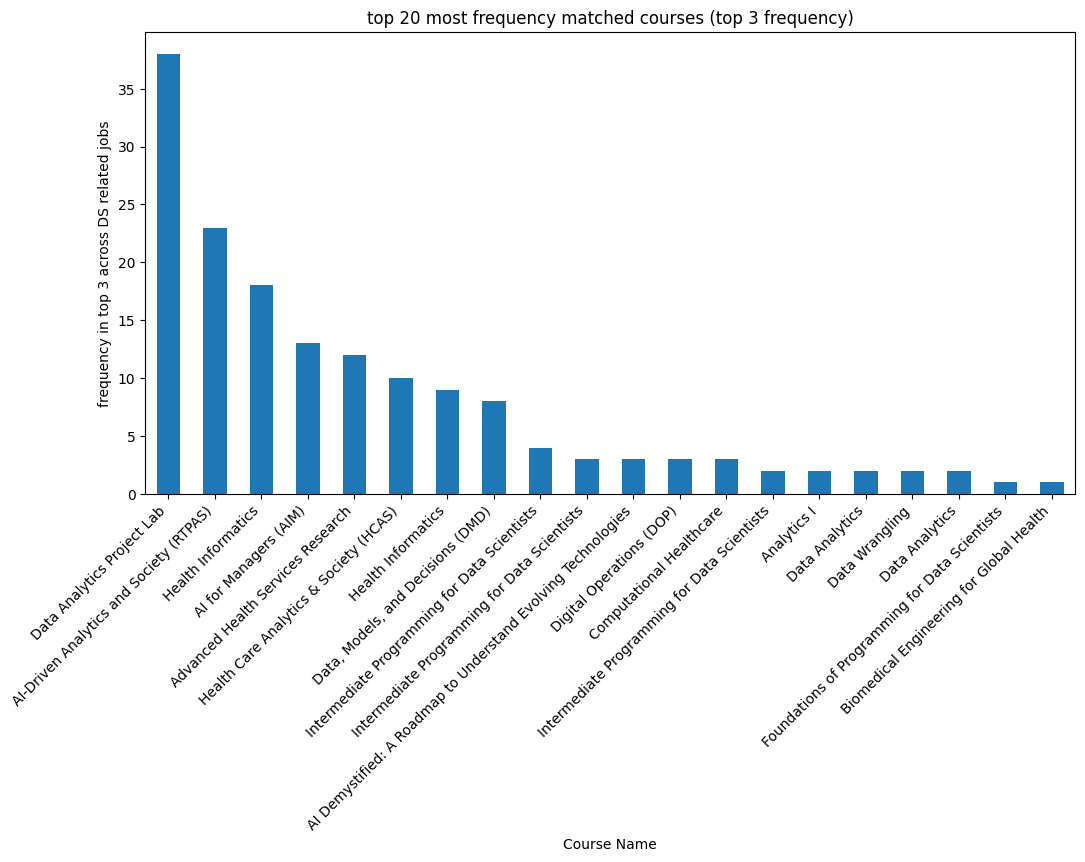

In [24]:
top_courses_df.head(20).plot.bar(
    y = 'count_in_top_K',
    x = 'course_name',
    figsize=(12,6),
    legend = False,
    title= 'top 20 most frequency matched courses (top 3 frequency)'
)
plt.xlabel('Course Name')
plt.ylabel('frequency in top 3 across DS related jobs')
plt.xticks(rotation=45, ha='right')
#plt.gca().invert_yaxis
plt.tight_layout
plt.show()

In [26]:
import plotly.express as px

In [31]:
top_df = top_courses_df.sort_values(by= 'count_in_top_K', ascending = False).head(20)
top_df['Course Link'] = top_df['course_url'].apply(lambda x: f'<a href="{x}" target="_blank">{x}</a>')

fig = px.bar(
    top_df,
    x='course_name',
    y='count_in_top_K',
    hover_data=['course_url'],
    title = 'top 20 most frequency matched courses (top 3 frequency)',
    labels = {'count_in_top_K': 'Frequency', 'course_name': 'Course Name'}
)
fig.update_layout(xaxis_tickangle=45)
fig.show()

In [21]:
# Ai related keywords
ai_keywords = ['LLM', 'large language model', 'GenAI', 'Generative AI',
'prompt engineering', 'foundation model', 'transformer',
'ChatGPT', 'GPT', 'BERT', 'embedding', 'self-attention']

In [65]:
ai_reference_text = [
"This text describes cutting-edge AI technologies and trends in data science job markets, "
"including Deep Learning (DL), large language models (LLMs), generative AI, reinforcement learning (RL), "
"foundation models, self-supervised learning, prompt engineering, transformers, "
"and applications like computer vision and NLP. "
"These AI advancements are increasingly integrated into modern data science roles and require specialized training in machine learning, deep learning, and scalable model deployment."
]

In [66]:
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')
ai_reference_embedding = model.encode(ai_reference_text, convert_to_tensor=True)

In [67]:
job_embeddings = model.encode(df_loaded_jobs['combined_text'].tolist(), convert_to_tensor=True)

In [68]:
similarity_scores = util.cos_sim(job_embeddings, ai_reference_embedding).squeeze().cpu().numpy()

In [69]:
similarity_scores.shape

(55,)

In [70]:
df_loaded_jobs['AI_similarity'] = similarity_scores

In [71]:
df_loaded_jobs[:3]

,Country,Company,Job Title,Job Description,URL,Full Job Description,combined_text,similarity_score,AI_related,AI_similarity
0,US,Eli Lilly,Data Scientist (R5-R7),"At Lilly, we unite caring with discovery to ma...",https://www.adzuna.com/details/5248534700?utm_...,"At Lilly, we unite caring with discovery to ma...","Data Scientist (R5-R7) At Lilly, we unite cari...",0.636731,False,0.570301
1,US,Eli Lilly,Data Scientist (R5-R7),"At Lilly, we unite caring with discovery to ma...",https://www.adzuna.com/details/5246717556?utm_...,"At Lilly, we unite caring with discovery to ma...","Data Scientist (R5-R7) At Lilly, we unite cari...",0.637432,False,0.571062
2,US,Eli Lilly,"Advisor Engineer - Data, Molecule Discovery","At Lilly, we unite caring with discovery to ma...",https://www.adzuna.com/details/5279054822?utm_...,"At Lilly, we unite caring with discovery to ma...","Advisor Engineer - Data, Molecule Discovery At...",0.508027,False,0.439169


In [72]:
threshold = 0.5
df_jobs_ai = df_loaded_jobs[df_loaded_jobs['AI_similarity']>= threshold].copy()
df_jobs_traditional = df_loaded_jobs[df_loaded_jobs['AI_similarity']<threshold].copy()


In [73]:
len(df_jobs_ai)

29

In [74]:
len(df_jobs_traditional)

26

In [75]:
df_loaded_courses_clean = df_loaded_courses['combined_text'].dropna().tolist()

In [76]:
len(df_loaded_courses_clean)

974

In [77]:
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('all-MiniLM-L6-v2')

# Combine course text
courses_text = df_loaded_courses_clean
course_embeddings = model.encode(courses_text, convert_to_tensor=True)

# AI Jobs
ai_job_embeddings = model.encode(df_jobs_ai['combined_text'].tolist(), convert_to_tensor=True)
similarity_ai = util.cos_sim(course_embeddings, ai_job_embeddings)

# Traditional Jobs

traditional_job_embeddings = model.encode(df_jobs_traditional['combined_text'].tolist(), convert_to_tensor=True)
similarity_traditional = util.cos_sim(course_embeddings, traditional_job_embeddings)

In [78]:
# Take average similarity per course
import pandas as pd

df_course_similarity = df_loaded_courses.copy()
df_course_similarity['AI_similarity'] = similarity_ai.mean(dim=1).cpu().numpy()
df_course_similarity['Traditional_similarity'] = similarity_traditional.mean(dim=1).cpu().numpy()
df_course_similarity['Alignment_trend'] = df_course_similarity['AI_similarity'] - df_course_similarity['Traditional_similarity']

In [61]:
len(df_course_similarity) # course

974

In [104]:
import matplotlib.pyplot as plt
df_course_similarity2 = df_course_similarity.sort_values('Alignment_trend' , ascending=False)

In [105]:
len(df_course_similarity2)
# alignment trend - indicating courses that have 1.5867 higher average similar to AI jobs than to traditional jobs, across many comparison 

974

In [106]:
df_course_similarity2[:5]

,course_code,course_name,course_description,course_url,combined_text,AI_similarity,Traditional_similarity,Alignment_trend
663,89.33,The Dark Side of AI/ML: Machine Learning Secur...,The goal of this course is to equip students t...,https://dartmouth.smartcatalogiq.com/en/curren...,The Dark Side of AI/ML: Machine Learning Secur...,0.353532,0.199201,0.154331
315,NaN,AI-Driven Analytics and Society (RTPAS),The last decade has brought us tremendous adva...,https://tuck.dartmouth.edu/mba/academic-experi...,AI-Driven Analytics and Society (RTPAS)The las...,0.533209,0.385077,0.148132
26,ENGS 15.08,AI Demystified: A Roadmap to Understand Evolvi...,AI Demystified unfolds the pivotal world of Ar...,https://engineering.dartmouth.edu/courses/unde...,AI Demystified: A Roadmap to Understand Evolvi...,0.470497,0.325676,0.144821
657,89.27,Security and Privacy of Machine Learning,Today we see applications of machine learning ...,https://dartmouth.smartcatalogiq.com/en/curren...,Security and Privacy of Machine LearningToday ...,0.331600,0.188060,0.143540
650,89.19,Machine Learning for Robotics,Machine Learning for Robotics is a course mixe...,https://dartmouth.smartcatalogiq.com/en/curren...,Machine Learning for RoboticsMachine Learning ...,0.305164,0.163133,0.142031


In [112]:
threshold2 = 0.25
top_aligned_ai = df_course_similarity2[(df_course_similarity2['AI_similarity']>= threshold2) & (df_course_similarity2['Alignment_trend']>0) & (df_course_similarity2['AI_similarity']> df_course_similarity2['Traditional_similarity'])].copy()
top_aligned_traditional = df_course_similarity2[(df_course_similarity2['Traditional_similarity']>=threshold2) & (df_course_similarity2['Alignment_trend']<0) & (df_course_similarity2['AI_similarity']<df_course_similarity2['Traditional_similarity'])].copy()


In [113]:
len(top_aligned_ai)

90

In [114]:
top_aligned_ai_sorted = top_aligned_ai.sort_values(by = 'AI_similarity', ascending=False)

In [115]:
top_aligned_ai_sorted[:-10]

,course_code,course_name,course_description,course_url,combined_text,AI_similarity,Traditional_similarity,Alignment_trend
226,ENGM 204,Data Analytics Project Lab,The widespread proliferation of IT-mediated ec...,https://engineering.dartmouth.edu/courses/grad...,Data Analytics Project LabThe widespread proli...,0.544147,0.474273,0.069874
315,NaN,AI-Driven Analytics and Society (RTPAS),The last decade has brought us tremendous adva...,https://tuck.dartmouth.edu/mba/academic-experi...,AI-Driven Analytics and Society (RTPAS)The las...,0.533209,0.385077,0.148132
354,NaN,AI for Managers (AIM),"In this minicourse, students will learn about ...",https://tuck.dartmouth.edu/mba/academic-experi...,"AI for Managers (AIM)In this minicourse, stude...",0.497257,0.381012,0.116245
26,ENGS 15.08,AI Demystified: A Roadmap to Understand Evolvi...,AI Demystified unfolds the pivotal world of Ar...,https://engineering.dartmouth.edu/courses/unde...,AI Demystified: A Roadmap to Understand Evolvi...,0.470497,0.325676,0.144821
364,NaN,"Data, Models, and Decisions (DMD)",DMD builds on the core Analytics courses and e...,https://tuck.dartmouth.edu/mba/academic-experi...,"Data, Models, and Decisions (DMD)DMD builds on...",0.456163,0.450281,0.005883
...,...,...,...,...,...,...,...,...
192,ENGM 189.20,Medical Device Development (.5 credit),This module of the course is an overview of ex...,https://engineering.dartmouth.edu/courses/grad...,Medical Device Development (.5 credit)This mod...,0.265141,0.250620,0.014521
193,ENGG 189.20,Medical Device Development (.5 credit),This module of the course is an overview of ex...,https://engineering.dartmouth.edu/courses/grad...,Medical Device Development (.5 credit)This mod...,0.265141,0.250620,0.014521
311,NaN,Tools for Improving Operations (TFIO),This minicourse covers frameworks and tools de...,https://tuck.dartmouth.edu/mba/academic-experi...,Tools for Improving Operations (TFIO)This mini...,0.263631,0.260830,0.002802
805,HSE 122,Biostatistics III: Modeling Complex Data,No Description found,https://dartmouth.smartcatalogiq.com/current/o...,Biostatistics III: Modeling Complex DataNo Des...,0.263126,0.255623,0.007504


In [116]:
len(top_aligned_traditional)

69

In [121]:
top_aligned_traditional_sorted = top_aligned_traditional.sort_values(by = 'Traditional_similarity', ascending=False)

In [122]:
top_aligned_traditional_sorted[:-5]

,course_code,course_name,course_description,course_url,combined_text,AI_similarity,Traditional_similarity,Alignment_trend
914,139,Advanced Health Services Research,This course will develop student analytic comp...,https://dartmouth.smartcatalogiq.com/en/curren...,Advanced Health Services ResearchThis course w...,0.424521,0.474983,-0.050462
648,89.17,Health Informatics,Our health is everywhere. It is aff\u000Bected...,https://dartmouth.smartcatalogiq.com/en/curren...,Health InformaticsOur health is everywhere. It...,0.450596,0.459923,-0.009326
924,192,Health Informatics,Our health is everywhere. It is affected by ho...,https://dartmouth.smartcatalogiq.com/en/curren...,Health InformaticsOur health is everywhere. It...,0.422808,0.445716,-0.022908
336,NaN,Health Care Analytics & Society (HCAS),This course is about health analytics in actio...,https://tuck.dartmouth.edu/mba/academic-experi...,Health Care Analytics & Society (HCAS)This cou...,0.439034,0.441250,-0.002216
943,NaN,Health Analytics,Data analytics can improve decision-making in ...,https://mha.dartmouth.edu/curriculum-schedule/...,Health AnalyticsData analytics can improve de...,0.397756,0.407694,-0.009939
...,...,...,...,...,...,...,...,...
212,ENGG 199.11,Master of Engineering Design Project Completion,This course is a follow-on to the winter term ...,https://engineering.dartmouth.edu/courses/grad...,Master of Engineering Design Project Completio...,0.242974,0.266863,-0.023889
958,NaN,HCDS AFE Accounting and Finance Essentials,"This course develops frameworks, tools, and mo...",https://dartmouth.smartcatalogiq.com/en/curren...,HCDS AFE Accounting and Finance EssentialsThis...,0.242764,0.263913,-0.021149
252,ENGG 325,Introduction to Surgical Innovation,Analysis of transmission structures and circui...,https://engineering.dartmouth.edu/courses/grad...,Introduction to Surgical InnovationAnalysis of...,0.248173,0.258694,-0.010521
400,145.0,"Practicum in combining theories, models, and d...","In science, models are the link between theori...",https://dartmouth.smartcatalogiq.com/en/curren...,"Practicum in combining theories, models, and d...",0.254341,0.257538,-0.003197


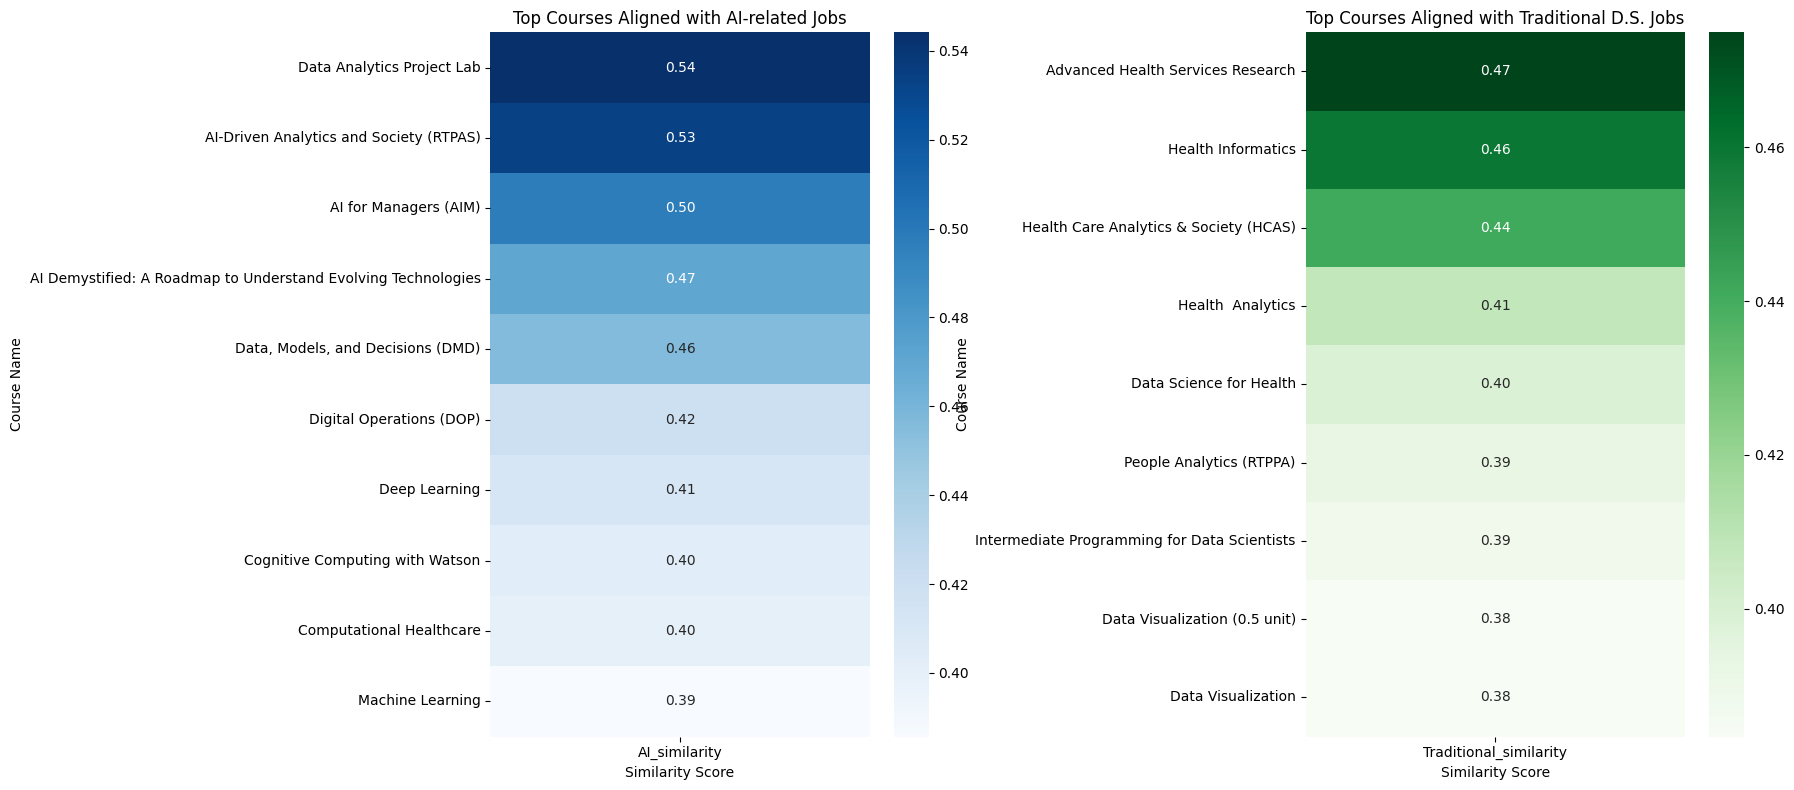

In [125]:
# Set up the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap for AI-aligned courses
sns.heatmap(
data=top_aligned_ai_sorted[:10].set_index("course_name")[["AI_similarity"]],
annot=True, cmap="Blues", fmt=".2f", ax=axes[0]
)
axes[0].set_title("Top Courses Aligned with AI-related Jobs")
axes[0].set_xlabel("Similarity Score")
axes[0].set_ylabel("Course Name")

# Heatmap for Traditional-aligned courses
sns.heatmap(
data=top_aligned_traditional_sorted[:10].drop_duplicates(subset='course_name').set_index("course_name")[["Traditional_similarity"]],
annot=True, cmap="Greens", fmt=".2f", ax=axes[1]
)
axes[1].set_title("Top Courses Aligned with Traditional D.S. Jobs")
axes[1].set_xlabel("Similarity Score")
axes[1].set_ylabel("Course Name")

plt.tight_layout()
plt.show()